# Hamiltonian Simulation: Real-Time Dynamics

This notebook solves a small real-time Schrodinger dynamics problem by applying the matrix function `exp(-iHt)` to an initial state. QSVT can express real and imaginary parts of this unitary evolution through bounded polynomial transforms of a rescaled Hamiltonian.

## Notebook guide

- **Learning objective:** simulate finite real-time dynamics with coherent QSVT.
- **Prerequisites:** an editable repository install, the relevant tutorial workflow, and basic spectral linear algebra.
- **Estimated runtime:** about 1–3 minutes on a local CPU.
- **Navigation:** [collection index](README.md) · [previous](01_poisson_equation_pde.ipynb) · [next](03_greens_function_response.ipynb).


## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a small tight-binding Schrödinger dynamics problem.

**QSVT implementation.** It approximates the cosine and sine components of time evolution, synthesizes their QSVT phases, and coherently combines the forward/adjoint sequences with a selector LCU through the stable high-level workflow. The matrices are deliberately small so the rescaling, polynomial targets, finite circuit, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Exact spectral time evolution validates site probabilities and phase response. Hamiltonian simulation is a central quantum use case for block-encoded operators; this notebook keeps the instance tiny to make the transform transparent. Its `finite_qsvt` acceptance scope includes coherent sequence combination, measured selector postselection, and a concrete finite circuit-resource ledger while leaving scalable access, state preparation, amplification, and readout explicit.


## Variable definitions

- $H$ is the tight-binding Hamiltonian, $t$ is the evolution time, and $i=\sqrt{-1}$.
- $U(t)=e^{-iHt}$ is the exact propagator; $|\psi_0\rangle$ and $|\psi(t)\rangle=U(t)|\psi_0\rangle$ are the initial and evolved states.
- With spectral scale $s$, $A=H/s$ lies in the polynomial domain and $\tau=st$ is the dimensionless evolution time.
- $P_c(A)$ and $P_s(A)$ approximate $\cos(\tau A)$ and $\sin(\tau A)$ in the polynomial simulation.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.polynomials import eval_polynomial
from qsvt.spectral import eigh_hermitian
from qsvt.hamiltonians import tight_binding_chain
from notebooks._support import display_table
from qsvt.stable import hamiltonian_simulation_workflow

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_sites = 6
time = 1.4
H = tight_binding_chain(n_sites)
evals, _ = eigh_hermitian(H)

psi0 = np.zeros(n_sites, dtype=complex)
psi0[1] = 1.0

simulation = hamiltonian_simulation_workflow(
    H,
    psi0,
    time=time,
    degree=19,
    acceptance_tolerance=1e-6,
)
scale = simulation.scaled_operator.scale
A = simulation.scaled_operator.matrix
tau = simulation.scaled_time
U_poly_psi = simulation.evolved_state
U_exact_psi = simulation.reference_state
state_error = simulation.state_relative_error
acceptance = simulation.as_report()["acceptance"]

display_table(
    "Hamiltonian simulation acceptance checks",
    acceptance["checks"],
    [
        ("criterion", lambda row: row["id"]),
        ("required for scope", lambda row: row["required_for_scope"]),
        ("required for full QSVT", lambda row: row["required_for_full_qsvt"]),
        ("passed", lambda row: row["passed"]),
    ],
    layout="rows",
)
print(f"State Error: {state_error}")
print(f"acceptance: {acceptance['status']} (scope={acceptance['scope']}, full_qsvt={acceptance['full_qsvt_acceptance']})")

Hamiltonian simulation acceptance checks
----------------------------------------
criterion                  required for scope  required for full QSVT  passed
-------------------------  ------------------  ----------------------  ------
classical_reference        True                True                    True  
polynomial_accuracy        True                True                    True  
norm_preservation          True                True                    True  
finite_qsvt_execution      True                True                    True  
diagnostics_and_resources  True                True                    True  
State Error: 1.803564790220685e-15
acceptance: accepted_for_stated_scope (scope=finite_qsvt, full_qsvt=True)


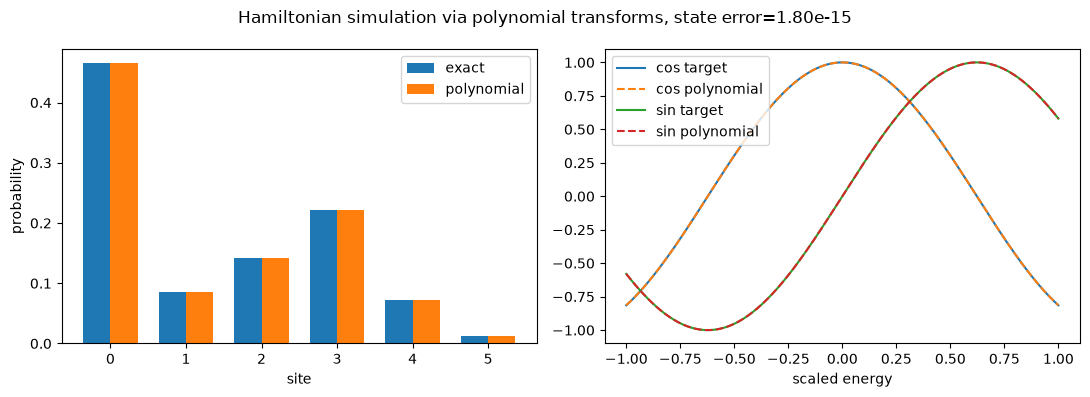

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(np.arange(n_sites) - 0.18, np.abs(U_exact_psi) ** 2, 0.36, label="exact")
axes[0].bar(
    np.arange(n_sites) + 0.18, np.abs(U_poly_psi) ** 2, 0.36, label="polynomial"
)
axes[0].set_xlabel("site")
axes[0].set_ylabel("probability")
axes[0].legend()

xs = np.linspace(-1, 1, 500)
axes[1].plot(xs, np.cos(tau * xs), label="cos target")
axes[1].plot(
    xs, eval_polynomial(simulation.cos_coeffs, xs), "--", label="cos polynomial"
)
axes[1].plot(xs, np.sin(tau * xs), label="sin target")
axes[1].plot(
    xs, eval_polynomial(simulation.sin_coeffs, xs), "--", label="sin polynomial"
)
axes[1].set_xlabel("scaled energy")
axes[1].legend()
fig.suptitle(
    f"Hamiltonian simulation via polynomial transforms, state error={state_error:.2e}"
)
plt.tight_layout()
plt.show()

## Takeaways and next steps

- **Result:** The workflow shows how to simulate finite real-time dynamics with coherent QSVT.
- **Interpretation boundary:** This is a finite, simulator-scale application client; input, readout, and scalability assumptions remain explicit.
- **Continue:** [collection index](README.md) · [previous](01_poisson_equation_pde.ipynb) · [next](03_greens_function_response.ipynb).
